# **LSTM**


## Importing the required modules


In [1]:
import numpy as np
import os
import librosa
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

def extract_features(file_path):
    audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccs_processed = np.mean(mfccs.T, axis=0)
    return mfccs_processed

def load_data(data_path):
    features = []
    labels = []
    
    for folder in os.listdir(data_path):
        if folder.startswith('.'):
            continue
        class_label = folder
        class_dir = os.path.join(data_path, class_label)
        
        for file in os.listdir(class_dir):
            if file.endswith('.wav'):
                file_path = os.path.join(class_dir, file)
                data = extract_features(file_path)
                features.append(data)
                labels.append(class_label)
    
    features = np.array(features)
    labels = np.array(labels)
    
    return features, labels

# Example usage
data_path = 'E:/SARAVANAN-2024-2025/STUDENT OWN CONCEPT/B1302/DEEP FAKE DETECTION/RESOURCES/Deepfake_detection_using_deep_learning-master/DATASET/TRAIN/'
X, y = load_data(data_path)

# Encode the labels
le = LabelEncoder()
y_encoded = to_categorical(le.fit_transform(y))

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, input_shape=(X.shape[1], 1), return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(128))
model.add(Dropout(0.3))
model.add(Dense(y_encoded.shape[1], activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# Reshape the data for LSTM
X_reshaped = np.expand_dims(X, axis=-1)

# Train the model
history = model.fit(X_reshaped, y_encoded, epochs=100, batch_size=32, validation_split=0.2)

# Save the model
model.save('Deepfake.h5')


C:\Users\SPIRO-PYTHON1\AppData\Local\Temp\ipykernel_4892\2534338536.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 40, 128)           66560     
                                                                 
 dropout (Dropout)           (None, 40, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 128)               131584    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense (Dense)               (None, 2)                 258       
                                                                 
Total params: 198402 (775.01 KB)
Trainable params: 198402 (775.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/100
25/2

C:\Users\SPIRO-PYTHON1\AppData\Roaming\Python\Python39\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


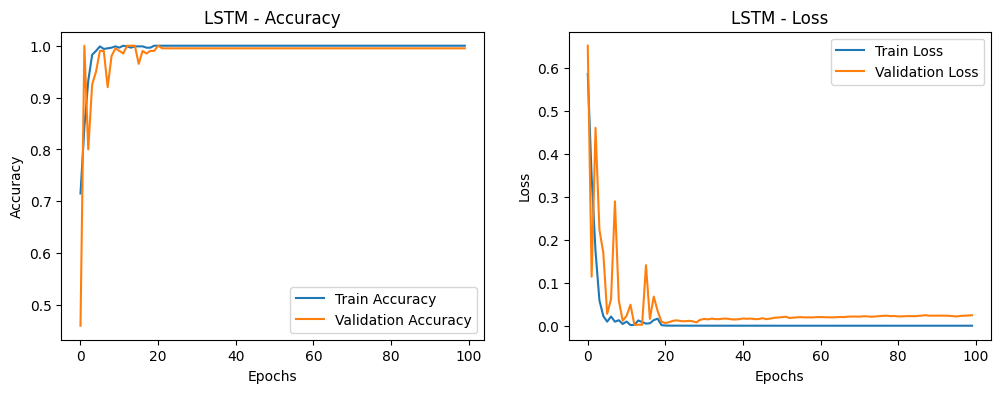

In [2]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()



# Visualize SimpleRNN model training history
plot_history(history, 'LSTM')



